In [1]:
import sys, os, importlib
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import pandas as pd
import config
import functions2 as f2
import functions1 as f1
import fx_hedges.fxshort_gates
import yfinance as yf
import config
import requests
from config import params
importlib.reload(fx_hedges.fxshort_gates)
importlib.reload(f2)
importlib.reload(f1)

<module 'functions1' from '/Users/alexwebb/laptop_coding/risk_matrix/functions1.py'>

In [2]:
datasource = params['datasource']
ticker = 'ULVR.UK'
window_start = '2019-01-01'
window_end = '2022-01-01'

In [5]:

s = f2.get_series(ticker, window_start, window_end)
# get trimmed start date
start_trimmed = s.index[0].strftime('%Y-%m-%d')
end_trimmed = s.index[-1].strftime('%Y-%m-%d')
print(f'trimmed series for {ticker} with {len(s)} rows, from {start_trimmed} to {end_trimmed}')


++++ get_seriesULVR.UK
gap days: 3
required start: 2016-01-01 
data start: 2016-01-04
sort_cols: ohlc not set. True only needed for ATR calculations for vol stops. Defaulting to False
trimmed series for ULVR.UK with 760 rows, from 2019-01-02 to 2021-12-31


In [ ]:


position = 1000
trim_pct = 0.10
take_profit_pct = 0.10

entry_price = s.iloc[0]
initial_position = position
initial_value = (entry_price * position) / 100

print('entry date', s.index[0].date(), 'at price', f"{entry_price:.2f}")
print(f"Position: {position} shares")
print(f"Initial position value: {initial_value:.0f}")


#  Loop through series and apply take-profit logic
total_cash = 0.0  # gross sale proceeds
tot_realized_pnl = 0.0
pnl_snapshots = []
trim_dates = []
trim_date = None

last_price = entry_price
low = entry_price
print('----LOOP-----')
for date, price in s.items():
    # if price < low:
        # print('-----new low', price)
    low = min(price, low)
    if (price / low - 1) > take_profit_pct:
        # print('=' * 20)
        # print(f"/////// Take profit on {date.date()} at price {price:.2f}")
        trim_date = date
        # last_price = price
        # print('trim_date set to:', trim_date.date())

        low = price  # reset low after take-profit trigger
        # print('+++++low reset to:', low)

        # PnL before trim on full current position
        pnl_before = ((price - entry_price) * position) / 100
        # print(f"Value before trim: {(price * position) / 100:.0f}")
        # print(f"PnL before trim ({position:.0f} sh): {pnl_before:.0f}")
        # print('.......')

        # Trim a fraction of current shares
        shares_to_trim = position * trim_pct
        this_pnl = ((price - entry_price) * shares_to_trim) / 100
        tot_realized_pnl += this_pnl
        cash = (price * shares_to_trim) / 100
        total_cash += cash
        position -= shares_to_trim

        unrealized_pnl = ((price - entry_price) * position) / 100
        total_pnl = tot_realized_pnl + unrealized_pnl

        trim_dates.append((trim_date, price, this_pnl))

        # print(f"Trimmed shares: {shares_to_trim:.0f} leaves {position:.0f}")
        # print(f"Cash (sale proceeds): {cash:.0f}")
        # print(f"PnL from trimmed shares: {this_pnl:.0f}")
        # print(f"Total Realized PnL: {tot_realized_pnl:.0f}")
        # print(f"Unrealized PnL: {unrealized_pnl:.0f}")
        # print(f"Total PnL after trim: {total_pnl:.0f}")
        # print('value after trim:', round((price * position) / 100))

        # break
# print('=======END=======')
if trim_date is None:
    print('No take-profit trigger hit in sample window.')
# for d in trim_dates:
    # print('Trim date:', d[0].date(), 'at price', f"{d[1]:.2f}")
print('total_cash from trims:', round(total_cash))
nav_after_trims = total_cash + (s.iloc[-1] * position) / 100
nav_without_trims = (s.iloc[-1] * initial_position) / 100
trim_pnl = nav_after_trims - nav_without_trims
print('final NAV after trimming: ', round(nav_after_trims))
print('final NAV without trimming: ', round(nav_without_trims))
print('PnL from trims:', round(trim_pnl))


entry date 2019-01-02 at price 3491.72
Position: 1000 shares
Initial position value: 34917
----LOOP-----
Trim date: 2019-03-21 at price 3737.40
Trim date: 2019-05-16 at price 4087.70
Trim date: 2019-08-30 at price 4482.02
Trim date: 2020-02-06 at price 4081.67
Trim date: 2020-03-18 at price 3593.61
Trim date: 2020-05-28 at price 3825.23
Trim date: 2020-07-23 at price 4126.46
Trim date: 2020-10-13 at price 4340.22
Trim date: 2021-04-07 at price 3748.15
total_cash from trims: 24521
final NAV after trimming:  38759
final NAV without trimming:  36751
PnL from trims: 2008


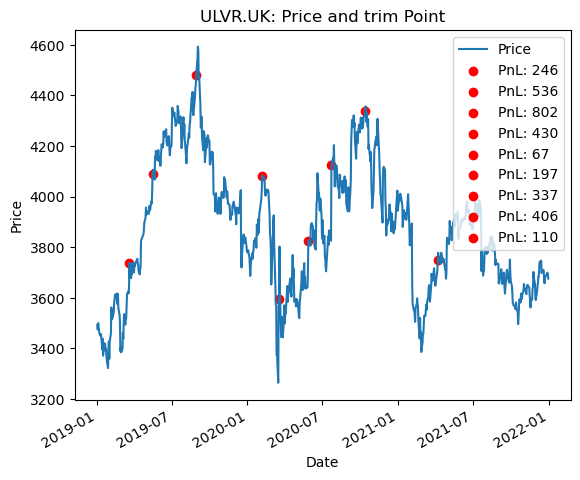

In [7]:
import matplotlib.dates as mdates
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1,7)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30, ha='right')
plt.tight_layout
plt.plot(s.index, s.values, label='Price')
for t in trim_dates:
    plt.scatter([t[0]], s.loc[t[0]], color='red', label=f"PnL: {t[2]:.0f}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title(f"{ticker}: Price and trim Point")
plt.legend()
plt.show()
